--- Stage 2: Positional Classifier Setup ---

1. Analyzing bounding box positional data...
Positional Statistics (Y-coordinate of BBox Center):
   Class  Mean Height  Median Height    Std Dev  Count
0  other   113.934840          106.5  80.866058   7543
1    rbc   123.864564          123.0  80.245750   3186
2    cbc    90.470474           75.5  64.187636   1033

2. Visualizing height distribution on a sample test image...


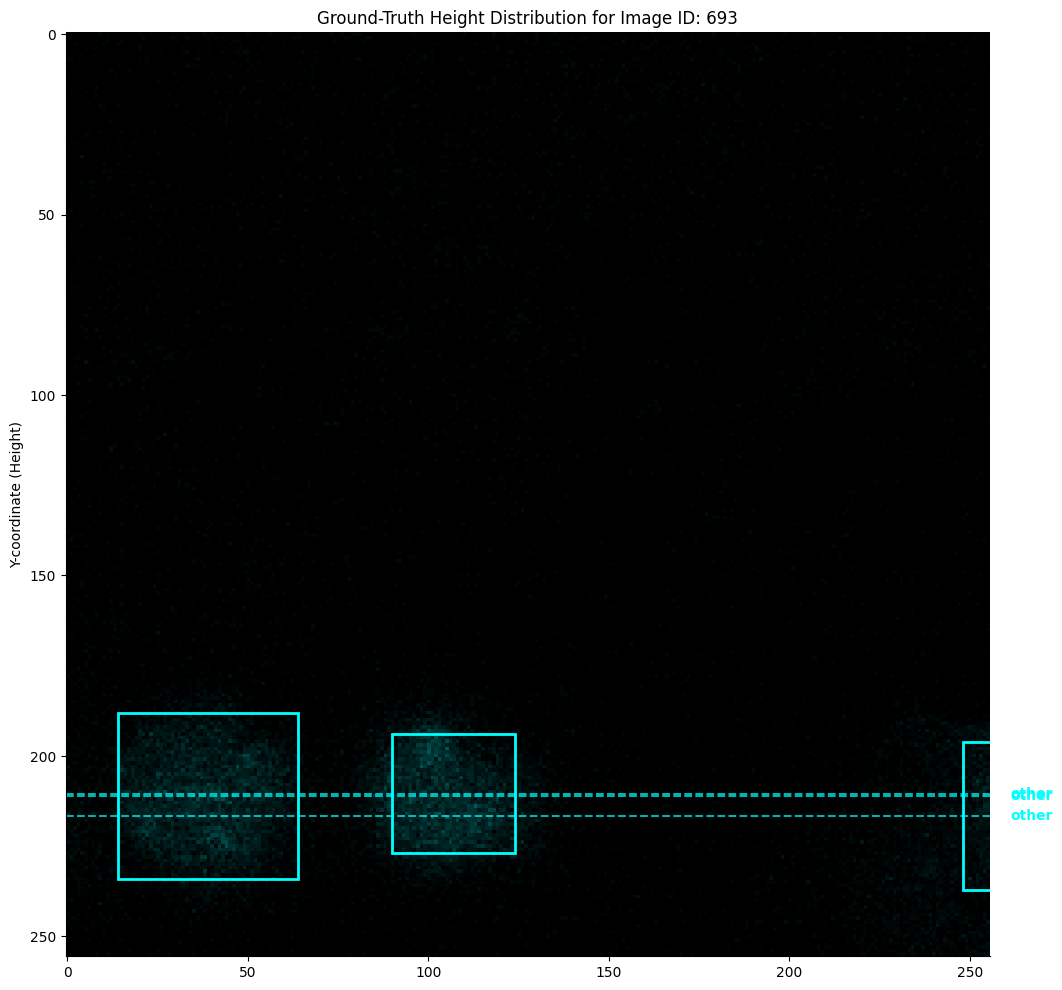


3. Training the positional classifier (Logistic Regression)...
Positional classifier trained successfully.

--- Evaluating Positional Model in Isolation ---

Classification Report for Positional Model (on rbc/cbc):
              precision    recall  f1-score   support

         rbc       0.77      1.00      0.87       676
         cbc       0.00      0.00      0.00       205

    accuracy                           0.77       881
   macro avg       0.38      0.50      0.43       881
weighted avg       0.59      0.77      0.67       881



c:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

NameError: name 'plot_confusion_matrix' is not defined

<Figure size 600x600 with 0 Axes>

In [1]:
import os
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import itertools
from pycocotools import mask as mask_util
from tqdm import tqdm

# --- 1. FILE PATHS AND CONFIGURATION ---
ANALYSIS_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis"
PROCESSED_DATA_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data"
JSON_FILE_PATH = os.path.join(PROCESSED_DATA_FOLDER, "patches", ".json")
IMAGE_FOLDER = os.path.join(PROCESSED_DATA_FOLDER, "patches")
STAGE_1_MODEL_PATH = os.path.join(ANALYSIS_FOLDER, 'maskrcnn_2class_weighted.pth')

# --- STAGE 1 (DETECTION) MODEL CONFIG ---
# This must match the model we are loading
# Classes were: 0: background, 1: other, 2: cell_of_interest
STAGE_1_NUM_CLASSES = 3

# --- STAGE 2 (CLASSIFICATION) FINAL CONFIG ---
# Final classes: 0: background, 1: other, 2: rbc, 3: cbc
FINAL_NUM_CLASSES = 4


# --- 2. DATASET CLASS (UNCHANGED FROM PREVIOUS) ---
# We use the same binary dataset class to load data for the Stage 1 model
class CellDataset(Dataset):
    def __init__(self, image_info, annotations, image_dir, transforms=None):
        self.image_info = image_info
        self.annotations = annotations
        self.image_dir = image_dir
        self.transforms = transforms
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.image_info)

    def __getitem__(self, idx):
        img_data = self.image_info[idx]
        img_path = os.path.join(PROCESSED_DATA_FOLDER, img_data['file_name'])
        try:
            image = Image.open(img_path).convert("RGB")
            width, height = image.size
        except FileNotFoundError:
            return None, None

        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])
        boxes, labels, masks = [], [], []
        
        for ann in anns:
            xmin, ymin, w, h = ann['bbox']
            xmax, ymax = xmin + w, ymin + h
            xmin, ymin, xmax, ymax = max(0, xmin), max(0, ymin), min(width, xmax), min(height, ymax)
            if xmax <= xmin or ymax <= ymin: continue
            
            original_id = ann['category_id']
            if original_id == 0: label = 1
            elif original_id in [1, 2]: label = 2
            else: continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)
            masks.append(mask_util.decode(ann['segmentation']))

        if not boxes:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {"boxes": boxes, "labels": labels, "masks": masks, "image_id": torch.tensor([img_id])}
        if self.transforms:
            image = torchvision.transforms.ToTensor()(image)
        return image, target

# --- 3. POSITIONAL DATA ANALYSIS & STAGE 2 MODEL TRAINING ---
print("--- Stage 2: Positional Classifier Setup ---")
# Load the full original dataset annotations
with open(JSON_FILE_PATH, 'r') as f:
    coco_data = json.load(f)
annotations = coco_data['annotations']
images = coco_data['images']
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)


# 1. Create summary statistics of bounding box heights
print("\n1. Analyzing bounding box positional data...")
positions = {'other': [], 'rbc': [], 'cbc': []}
for ann in annotations:
    # IMPORTANT NOTE: This uses the y-coordinate within the patch (0-256), not the absolute
    # coordinate from the original image (0-1024). This is a limitation of the current dataset.
    y_center = ann['bbox'][1] + ann['bbox'][3] / 2
    if ann['category_id'] == 0: positions['other'].append(y_center)
    elif ann['category_id'] == 1: positions['rbc'].append(y_center)
    elif ann['category_id'] == 2: positions['cbc'].append(y_center)

summary_stats = {
    "Class": ['other', 'rbc', 'cbc'],
    "Mean Height": [np.mean(positions['other']), np.mean(positions['rbc']), np.mean(positions['cbc'])],
    "Median Height": [np.median(positions['other']), np.median(positions['rbc']), np.median(positions['cbc'])],
    "Std Dev": [np.std(positions['other']), np.std(positions['rbc']), np.std(positions['cbc'])],
    "Count": [len(positions['other']), len(positions['rbc']), len(positions['cbc'])]
}
stats_df = pd.DataFrame(summary_stats)
print("Positional Statistics (Y-coordinate of BBox Center):")
print(stats_df)

# 2. Visualize height distribution on a sample test image
def visualize_height_distribution(sample_image_info, annotations, base_folder):
    """Draws an image with ground-truth boxes and horizontal lines indicating their height."""
    img_path = os.path.join(base_folder, sample_image_info['file_name'])
    image = Image.open(img_path).convert("RGB")
    
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)
    
    img_id = sample_image_info['id']
    img_anns = [ann for ann in annotations if ann['image_id'] == img_id]
    
    label_names = {0: 'other', 1: 'rbc', 2: 'cbc'}
    colors = {0: 'cyan', 1: 'lime', 2: 'magenta'}
    
    ax.set_title(f"Ground-Truth Height Distribution for Image ID: {img_id}")
    ax.set_ylabel("Y-coordinate (Height)")
    
    for ann in img_anns:
        box = ann['bbox']
        cat_id = ann['category_id']
        y_center = box[1] + box[3] / 2
        
        rect = patches.Rectangle((box[0], box[1]), box[2], box[3],
                                 linewidth=2, edgecolor=colors.get(cat_id, 'red'), facecolor='none')
        ax.add_patch(rect)
        ax.axhline(y=y_center, color=colors.get(cat_id, 'red'), linestyle='--', alpha=0.7)
        ax.text(image.width * 1.02, y_center, label_names.get(cat_id, 'Unknown'),
                color=colors.get(cat_id, 'red'), va='center', fontweight='bold')
                
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.show()

print("\n2. Visualizing height distribution on a sample test image...")
sample_img_info = next((img for img in test_imgs if any(ann['image_id'] == img['id'] for ann in annotations)), None)
if sample_img_info:
    visualize_height_distribution(sample_img_info, annotations, PROCESSED_DATA_FOLDER)
else:
    print("Could not find a test image with annotations to visualize.")


# 3. Train the positional classifier
print("\n3. Training the positional classifier (Logistic Regression)...")
X_train_pos, y_train_pos = [], []
for ann in annotations:
    if ann['category_id'] in [1, 2]: # Only rbc and cbc
        y_center = ann['bbox'][1] + ann['bbox'][3] / 2
        X_train_pos.append([y_center])
        y_train_pos.append(2 if ann['category_id'] == 1 else 3)

positional_model = LogisticRegression()
positional_model.fit(X_train_pos, y_train_pos)
print("Positional classifier trained successfully.")


# --- 3a. NEW: EVALUATE POSITIONAL MODEL IN ISOLATION ---
print("\n--- Evaluating Positional Model in Isolation ---")
test_img_ids = {img['id'] for img in test_imgs}
test_annotations = [ann for ann in annotations if ann['image_id'] in test_img_ids and ann['category_id'] in [1, 2]]

X_test_pos = [[ann['bbox'][1] + ann['bbox'][3] / 2] for ann in test_annotations]
y_test_pos_true = [2 if ann['category_id'] == 1 else 3 for ann in test_annotations]

if X_test_pos:
    y_test_pos_pred = positional_model.predict(X_test_pos)

    print("\nClassification Report for Positional Model (on rbc/cbc):")
    print(classification_report(y_test_pos_true, y_test_pos_pred, target_names=['rbc', 'cbc']))

    pos_cm = confusion_matrix(y_test_pos_true, y_test_pos_pred, labels=[2, 3])
    plt.figure(figsize=(6, 6))
    plot_confusion_matrix(pos_cm, classes=['rbc', 'cbc'], title='Positional Model Only Confusion Matrix')
else:
    print("No 'rbc' or 'cbc' annotations found in the test set for isolated evaluation.")


# --- 4. LOAD STAGE 1 (MASK R-CNN) MODEL ---
print("\n--- Loading Stage 1: Mask R-CNN Detector ---")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

stage1_model = get_model_instance_segmentation(STAGE_1_NUM_CLASSES)
stage1_model.load_state_dict(torch.load(STAGE_1_MODEL_PATH))
stage1_model.to(device)
stage1_model.eval()
print(f"Loaded Stage 1 model from {STAGE_1_MODEL_PATH}")


# --- 5. TWO-STAGE PREDICTION PIPELINE ---
print("\n--- Running Two-Stage Pipeline on Test Data ---")
test_dataset = CellDataset(test_imgs, annotations, IMAGE_FOLDER, transforms=True)
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch: return None, None
    return torch.stack([item[0] for item in batch]), [item[1] for item in batch]
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)


all_final_preds, all_final_labels, prediction_results = [], [], []
VISUAL_MODEL_WEIGHT, POSITIONAL_MODEL_WEIGHT = 0.5, 0.5

with torch.no_grad():
    for img_tensors, targets in tqdm(test_loader):
        if img_tensors is None: continue
        
        img_tensor, target = img_tensors[0].to(device), targets[0]

        if not len(target['boxes']): continue
        
        stage1_preds = stage1_model([img_tensor])[0]
        final_boxes, final_labels, final_scores = [], [], []

        for i in range(len(stage1_preds['boxes'])):
            score, label, box = stage1_preds['scores'][i].item(), stage1_preds['labels'][i].item(), stage1_preds['boxes'][i].cpu().numpy()

            if score < 0.5: continue

            if label == 1: # 'other' class
                final_boxes.append(box); final_scores.append(score); final_labels.append(1)
            
            elif label == 2: # 'cell_of_interest'
                y_center = np.array([[box[1] + (box[3] - box[1]) / 2]])
                pos_pred_label = positional_model.predict(y_center)[0]
                pos_pred_probs = positional_model.predict_proba(y_center)[0]
                pos_score = pos_pred_probs[np.where(positional_model.classes_ == pos_pred_label)][0]
                
                combined_score = (score * VISUAL_MODEL_WEIGHT) + (pos_score * POSITIONAL_MODEL_WEIGHT)
                
                final_boxes.append(box); final_scores.append(combined_score); final_labels.append(pos_pred_label)

        true_labels_original = []
        for ann in annotations:
            if ann['image_id'] == target['image_id'].item():
                true_labels_original.append(ann['category_id'] + 1 if ann['category_id'] == 0 else (2 if ann['category_id'] == 1 else 3))

        if final_labels: all_final_preds.append(final_labels[np.argmax(final_scores)])
        else: all_final_preds.append(0)
        
        if true_labels_original: all_final_labels.append(true_labels_original[0])
        else: all_final_labels.append(0)

        prediction_results.append({'image': img_tensor, 'boxes': np.array(final_boxes), 'labels': np.array(final_labels), 'scores': np.array(final_scores)})

# --- 6. VISUALIZATION AND FINAL EVALUATION ---
print("\n--- Final Results ---")
def visualize_final_prediction(result, threshold=0.5):
    img = result['image'].permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)
    label_names = {1: 'other', 2: 'rbc', 3: 'cbc'}; colors = {1: 'cyan', 2: 'lime', 3: 'magenta'}
    for i in range(len(result['boxes'])):
        if result['scores'][i] > threshold:
            box, label = result['boxes'][i], result['labels'][i]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], 
                                     linewidth=2, edgecolor=colors.get(label, 'red'), facecolor='none')
            ax.add_patch(rect)
            plt.text(box[0], box[1], f'{label_names.get(label, "Unk")}: {result["scores"][i]:.2f}', 
                     bbox=dict(facecolor=colors.get(label, 'red'), alpha=0.5))
    plt.axis('off'); plt.show()

print("\n1. Visualizing final predictions on test images...")
for i in range(min(5, len(prediction_results))):
    visualize_final_prediction(prediction_results[i])

print("\n2. Final Confusion Matrix:")
cm = confusion_matrix(all_final_labels, all_final_preds, labels=[0, 1, 2, 3])
class_names = ['Background', 'other', 'rbc', 'cbc']

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap); plt.title(title); plt.colorbar()
    tick_marks = np.arange(len(classes)); plt.xticks(tick_marks, classes, rotation=45); plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'; thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout(); plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.show()

plt.figure(figsize=(8, 8))
plot_confusion_matrix(cm, class_names, title='Two-Stage Model Confusion Matrix')
